# Libraries

In [1]:
# Import libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "abhinavraj19",\r\n  "key": "KGAT_2e5fb77cad1280d25009583ac1853dce"\r\n}'}

In [3]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!cat ~/.kaggle/kaggle.json

{
  "username": "abhinavraj19",
  "key": "KGAT_2e5fb77cad1280d25009583ac1853dce"
}

In [5]:
!cat ~/.kaggle/kaggle.json

{
  "username": "abhinavraj19",
  "key": "KGAT_2e5fb77cad1280d25009583ac1853dce"
}

In [6]:
{
  "username": "abhinavraj19",
  "key": "KGAT_2d76e4821e97be017cf784092119e7fc"
}

{'username': 'abhinavraj19', 'key': 'KGAT_2d76e4821e97be017cf784092119e7fc'}

In [8]:
!kaggle datasets download -d anaselmasry/breast-cancer-dataset

Dataset URL: https://www.kaggle.com/datasets/anaselmasry/breast-cancer-dataset
License(s): copyright-authors
 98% 3.85G/3.93G [00:34<00:01, 41.0MB/s]
100% 3.93G/3.93G [00:35<00:00, 120MB/s] 


In [10]:
import os
print(os.listdir("/content"))

['.config', 'BreaKHis_Total_dataset', 'kaggle.json', 'breast-cancer-dataset.zip', 'sample_data']


In [15]:
DATASET_PATH = "/content/BreaKHis_Total_dataset"

Creating train, test and validation data

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
DATASET_PATH = "/content/BreaKHis_Total_dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 6228 images belonging to 2 classes.
Found 1555 images belonging to 2 classes.


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Building a model

In [21]:
#model = tf.keras.Sequential([

#    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
#    tf.keras.layers.MaxPooling2D(),

 #   tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
 #   tf.keras.layers.MaxPooling2D(),

#    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
 #   tf.keras.layers.MaxPooling2D(),

  #  tf.keras.layers.Flatten(),

   # tf.keras.layers.Dense(128,activation="relu"),
    #tf.keras.layers.Dense(train_data.num_classes,activation="softmax")
#])

Compile

In [22]:
#model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

Train

In [23]:
#history = model.fit(
 #   train_data,
 #   validation_data=val_data,
 #  epochs=3
#)

### Data set size was huge, reducing number of images

In [24]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

Dataset

In [26]:
DATASET_PATH = "/content/BreaKHis_Total_dataset"

In [29]:
DATASET_PATH = Path(DATASET_PATH)

benign_images = list((DATASET_PATH/"benign").glob("*"))
malignant_images = list((DATASET_PATH/"malignant").glob("*"))

random.seed(42)
print("Benign Images:", len(benign_images))
print("Malignant Images:", len(malignant_images))

Benign Images: 2479
Malignant Images: 5304


In [31]:
benign_sampled = random.sample(benign_images, min(len(benign_images), 2000)) # Sample up to 2000 benign images
malignant_sampled = random.sample(malignant_images, min(len(malignant_images), 2000)) # Sample up to 2000 malignant images

In [32]:
print("Sampled Benign Images:", len(benign_sampled))
print("Sampled Malignant Images:", len(malignant_sampled))

Sampled Benign Images: 2000
Sampled Malignant Images: 2000


In [33]:
files = []
labels = []

for f in benign_sampled:
    files.append(str(f))
    labels.append(0) # 0 for benign

for f in malignant_sampled:
    files.append(str(f))
    labels.append(1) # 1 for malignant

print("Total sampled images:", len(files))

Total sampled images: 4000


In [50]:
from sklearn.model_selection import train_test_split
import numpy as np

# Reconstruct files and labels to ensure consistency
files = []
labels = []

for f in benign_sampled:
    files.append(str(f))
    labels.append(0) # 0 for benign

for f in malignant_sampled:
    files.append(str(f))
    labels.append(1) # 1 for malignant

# Convert to numpy arrays for robust splitting
files_np = np.array(files)
labels_np = np.array(labels)

train_files, test_files, train_labels, test_labels = train_test_split(
    files_np, labels_np, test_size=0.15, random_state=42, stratify=labels_np
)

train_files, val_files, train_labels, val_labels = train_test_split(
    train_files, train_labels, test_size=0.15, random_state=42, stratify=train_labels
)

print(len(train_files), len(val_files), len(test_files))

2890 510 600


In [37]:
IMG_SIZE = (128,128)

def preprocess(path, label):

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, IMG_SIZE)

    img = tf.cast(img, tf.float32)/255.0

    return img, label

In [38]:
def create_dataset(files, labels):

    ds = tf.data.Dataset.from_tensor_slices((files, labels))

    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(32)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [39]:
train_ds = create_dataset(train_files, train_labels)
val_ds = create_dataset(val_files, val_labels)
test_ds = create_dataset(test_files, test_labels)

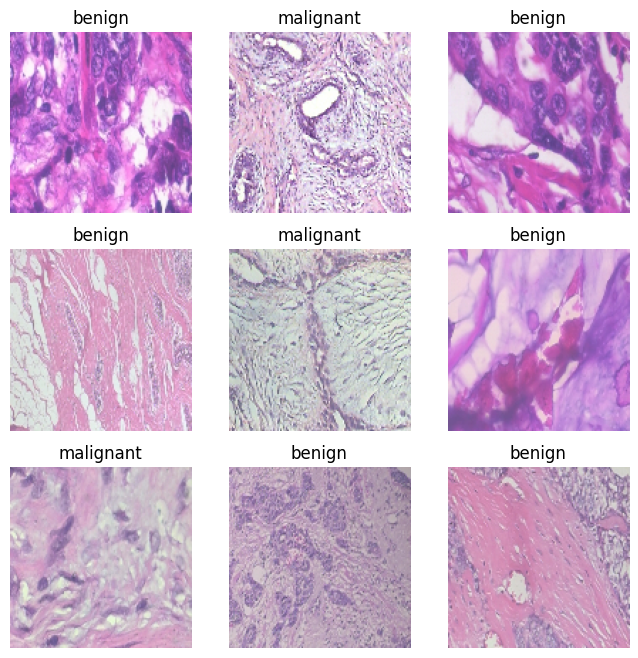

In [51]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.title("benign" if labels[i]==1 else "malignant")

        plt.axis("off")

plt.show()

In [59]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dense(1,activation="sigmoid")
])

In [60]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [61]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5
)
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

Epoch 1/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 30s 295ms/step - accuracy: 0.7218 - loss: 0.5725 - val_accuracy: 0.7765 - val_loss: 0.5054
Epoch 2/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 23s 257ms/step - accuracy: 0.7675 - loss: 0.5081 - val_accuracy: 0.7529 - val_loss: 0.5295
Epoch 3/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 43s 278ms/step - accuracy: 0.7799 - loss: 0.4983 - val_accuracy: 0.7647 - val_loss: 0.5220
Epoch 4/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 40s 268ms/step - accuracy: 0.7865 - loss: 0.4939 - val_accuracy: 0.7725 - val_loss: 0.5145
Epoch 5/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 42s 274ms/step - accuracy: 0.7903 - loss: 0.4875 - val_accuracy: 0.7882 - val_loss: 0.4973
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.7817 - loss: 0.4952
Test Accuracy: 0.7816666960716248


In [62]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.7817 - loss: 0.4952
Test Accuracy: 0.7816666960716248


# Quantum CNN

In [45]:
# Install PennyLane
!pip install pennylane pennylane-lightning -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pennylane as qml
import numpy as np

############################################
# Convert TensorFlow Dataset → NumPy
############################################

def tf_to_numpy(dataset):

    images = []
    labels = []

    for x, y in dataset:
        images.append(x.numpy())
        labels.append(y.numpy())

    images = np.concatenate(images)
    labels = np.concatenate(labels)

    return images, labels


X_train, y_train = tf_to_numpy(train_ds)
X_test, y_test   = tf_to_numpy(test_ds)

############################################
# Convert NumPy → PyTorch
############################################

X_train = torch.tensor(X_train).permute(0,3,1,2).float()
X_test  = torch.tensor(X_test).permute(0,3,1,2).float()

y_train = torch.tensor(y_train).float()
y_test  = torch.tensor(y_test).float()

############################################
# DataLoader
############################################

train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
testloader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

############################################
# Quantum Circuit
############################################

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")

def quantum_circuit(inputs, weights):

    qml.AngleEmbedding(inputs, wires=range(n_qubits))

    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


weight_shapes = {"weights": (3, n_qubits, 3)}

quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

############################################
# Hybrid Quantum CNN
############################################

class HybridQCNN(nn.Module):

    def __init__(self):

        super(HybridQCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((7,7))
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(8 * 7 * 7, 4)

        self.quantum = quantum_layer

        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):

        x = self.conv(x)

        x = self.flatten(x)

        x = self.fc1(x)

        x = torch.tanh(x)

        x = self.quantum(x)

        x = self.fc2(x)

        return torch.sigmoid(x)


model = HybridQCNN()

############################################
# Training Setup
############################################

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

############################################
# Training
############################################

for epoch in range(5):

    running_loss = 0.0

    for images, labels in trainloader:

        labels = labels.unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")


############################################
# Testing
############################################

correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:

        labels = labels.unsqueeze(1)

        outputs = model(images)

        predicted = (outputs > 0.5).float()

        total += labels.size(0)

        correct += (predicted == labels).sum().item()


accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 89.6 MB/s eta 0:00:00
Epoch 1, Loss: 0.6921
Epoch 2, Loss: 0.6596
Epoch 3, Loss: 0.6205
Epoch 4, Loss: 0.5805
Epoch 5, Loss: 0.5491
Test Accuracy: 81.33%


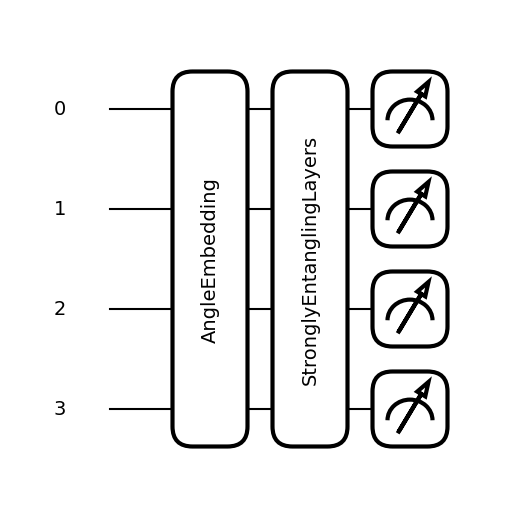

In [48]:
import matplotlib.pyplot as plt
import torch

# Define sample inputs and weights for drawing the circuit
sample_inputs = torch.randn(n_qubits) # n_qubits is 4 from earlier definition
sample_weights = torch.randn(3, n_qubits, 3) # Matches weight_shapes: (3, n_qubits, 3)

# Draw with matplotlib
fig, ax = qml.draw_mpl(quantum_circuit)(sample_inputs, sample_weights)
plt.show()

# Save the figure
fig.savefig('quantum_circuit.png', dpi=300, bbox_inches='tight')

In [49]:
print(qml.draw(quantum_circuit)(torch.randn(4), torch.randn(3,4,3)))

0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
3: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤  <Z>

M0 = 
tensor([-0.3667,  1.5784,  0.3441,  0.2705])
M1 = 
tensor([[[-0.6042, -0.2314,  0.6366],
         [ 0.6032, -0.1408,  0.8467],
         [-0.9590,  0.5743,  0.3817],
         [-0.2591, -0.5120, -0.3364]],

        [[-0.3203,  0.1019,  0.2011],
         [ 0.0978,  1.3933, -0.4334],
         [-1.3245,  1.7944, -0.4924],
         [ 0.3312, -1.1729, -0.4160]],

        [[ 0.6557, -0.0926,  1.0166],
         [ 0.5324,  1.5583, -0.2679],
         [-0.6090, -0.4624,  1.0524],
         [-0.7145,  1.4886,  0.2582]]])


# Improvements to the quantum circuit